# Reinforcement Learning Model Analysis 

In [6]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from rliable import library as rly
from rliable import metrics
from rliable import plot_utils

file_name = '/Users/jojona/Documents/Learning/Masters/COMPSCI 760/COMPSCI_760_Reinforcement/Atari/model_data/feudal_MsPacman-v5'
with open(file_name, 'r') as f:
    data = json.load(f)
    
print(data)



{'0': 460.0, '1': 1880.0, '2': 1950.0, '3': 430.0, '4': 260.0, '5': 370.0, '6': 290.0, '7': 620.0, '8': 320.0, '9': 230.0, '10': 730.0, '11': 100.0, '12': 1110.0, '13': 510.0, '14': 390.0, '15': 530.0, '16': 160.0, '17': 540.0, '18': 460.0, '19': 480.0, '20': 100.0, '21': 120.0, '22': 440.0, '23': 320.0, '24': 590.0, '25': 1880.0, '26': 210.0, '27': 550.0, '28': 200.0, '29': 390.0, '30': 500.0, '31': 130.0, '32': 1070.0, '33': 520.0, '34': 130.0, '35': 450.0, '36': 510.0, '37': 280.0, '38': 1880.0, '39': 900.0, '40': 940.0, '41': 370.0, '42': 710.0, '43': 600.0, '44': 180.0, '45': 330.0, '46': 400.0, '47': 840.0, '48': 710.0, '49': 450.0, '50': 140.0, '51': 220.0, '52': 1200.0, '53': 650.0, '54': 380.0, '55': 450.0, '56': 370.0, '57': 710.0, '58': 400.0, '59': 420.0, '60': 370.0, '61': 240.0, '62': 300.0, '63': 750.0, '64': 440.0, '65': 550.0, '66': 590.0, '67': 470.0, '68': 360.0, '69': 800.0, '70': 480.0, '71': 520.0, '72': 670.0, '73': 3340.0, '74': 480.0, '75': 570.0, '76': 350.0, 

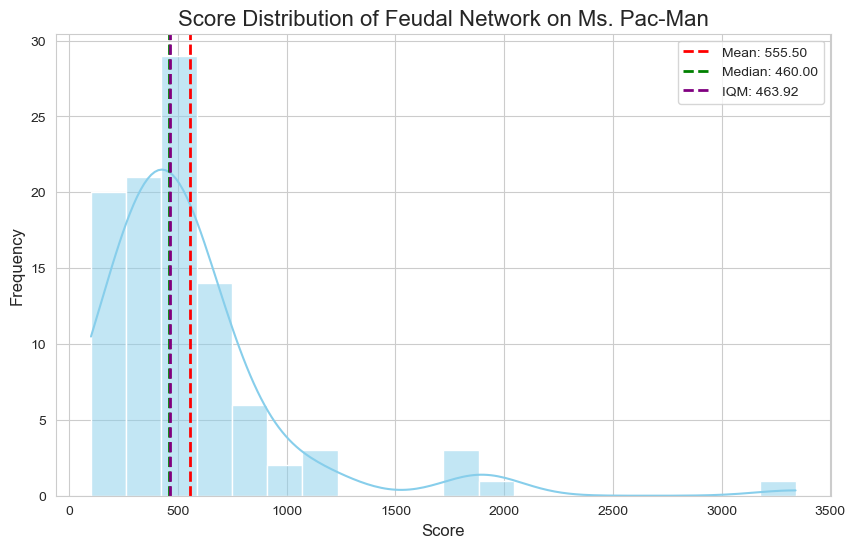

In [7]:

df = pd.DataFrame(list(data.items()), columns=['game', 'score'])
df['score'] = pd.to_numeric(df['score'])
mean_score = df['score'].mean()
median_score = df['score'].median()

# Calculate IQM
q1 = df['score'].quantile(0.25)
q3 = df['score'].quantile(0.75)
iqm_score = df[(df['score'] >= q1) & (df['score'] <= q3)]['score'].mean()
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Plot the histogram of scores with a KDE line
sns.histplot(df['score'], bins=20, kde=True, color='skyblue')

# Add vertical lines for the mean, median, and IQM
plt.axvline(mean_score, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_score:.2f}')
plt.axvline(median_score, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_score:.2f}')
plt.axvline(iqm_score, color='purple', linestyle='dashed', linewidth=2, label=f'IQM: {iqm_score:.2f}')
plt.title('Score Distribution of Feudal Network on Ms. Pac-Man', fontsize=16)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.show()

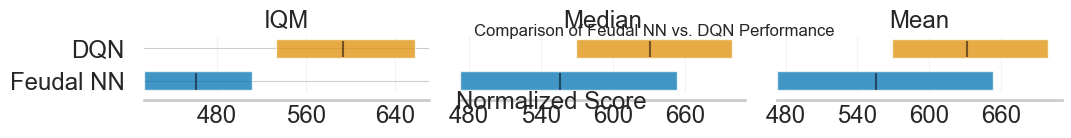

In [8]:
# Simulate DQN data for comparison, not real data
np.random.seed(42)
dqn_data_list = np.random.randint(200, 1000, size=100)
dqn_data_list[np.random.randint(0, 100, 3)] = 2000 # Add some outliers
dqn_data = {str(i): float(v) for i, v in enumerate(dqn_data_list)}

# Reshape Data for rliable 
# Shape must be (number_of_runs, number_of_tasks)
feudal_nn_scores = np.array(list(data.values())).reshape(100, 1)
dqn_scores = np.array(list(dqn_data.values())).reshape(100, 1)

scores_dict = {
    'Feudal NN': feudal_nn_scores,
    'DQN': dqn_scores
}
algorithms = list(scores_dict.keys())

# Define metrics(IQM, Median, and Mean)
aggregate_func = lambda x: np.array([
    metrics.aggregate_iqm(x),
    metrics.aggregate_median(x),
    metrics.aggregate_mean(x)
])
metric_names = ['IQM', 'Median', 'Mean']
aggregate_scores, aggregate_cis = rly.get_interval_estimates(
    scores_dict,
    aggregate_func,
    reps=50000)

# Plot the results
fig, axes = plot_utils.plot_interval_estimates(
    aggregate_scores,
    aggregate_cis,
    metric_names=metric_names,
    algorithms=algorithms,
    xlabel_fn=lambda x: f'{x} Score')

plt.suptitle("Comparison of Feudal NN vs. DQN Performance", y=1.05)
plt.show()